# Illustrative small-scale training run

In this notebook we present, for illustrative purposes only, a compacted version of the training process for HPS-CNN. There is an alternating sequence of neural network training stages and PDE solver (HPS) applications. This notebook contains a simplified training run to help demonstrate how the different stages work together. For readability, we have omitted certain features like parallelizing PDE solves across cluster nodes, selecting weights from the best epoch, Weights and Biases logging, etc., so the performance of code included in this notebook should not be taken as being fully representative of the implementation presented for our paper.

Within this notebook and code repository, we refer to the learned component of HPS-CNN's refinement blocks (i.e., the CNN component) as `MMGUBlock` for measurement-misfit-gradient update block.

Note that this notebook uses a reduced size dataset and training duration since the goal is not to achieve the numbers reported in the paper but to provide a small-scale run for easier interactivity.

<div style="background-color: #fef08a; border: 4px solid #000000; border-radius: 6px; padding: 18px; color: #000000; font-family: sans-serif; font-size: 20px; line-height: 1.5;">
  <p style="font-size: 24px; font-weight: 900; margin: 0 0 8px 0; text-transform: uppercase;">
    🚨 DISCLAIMER 🚨
  </p>
  <p style="margin: 0; font-weight: 500;">
    This notebook is intended for demonstrative purposes only to illustrate how all the pieces fit together: this code has not been optimized or rigorously tested, and it is run with relatively few data samples.
    <b>This notebook's code should not be used for comparison against our method.</b>
    Instead, we ask that you refer to <span style="font-family: monospace;">train_FYNet.py</span>, <span style="font-family: monospace;">run_recursive_linearization.py</span>, and <span style="font-family: monospace;">train_MMGUBlock.py</span>. We provide automated pipeline generation/submission in <span style="font-family: monospace;">generate_pipeline_scripts.py</span> and <span style="font-family: monospace;">submit_pipeline_scripts.py</span>, respectively. The configuration files for the training pipelines we conducted for our paper are located in the <span style="font-family: monospace;">experiments/hpscnn/</span> directory.
  </p>
</div>

In [10]:
# Display a diagram of the HPS-CNN architecture
# from IPython.display import SVG, display
# display(SVG(filename=".github/assets/hpscnn-assets/hpscnn_architecture_both.svg")) # does not render in github's preview

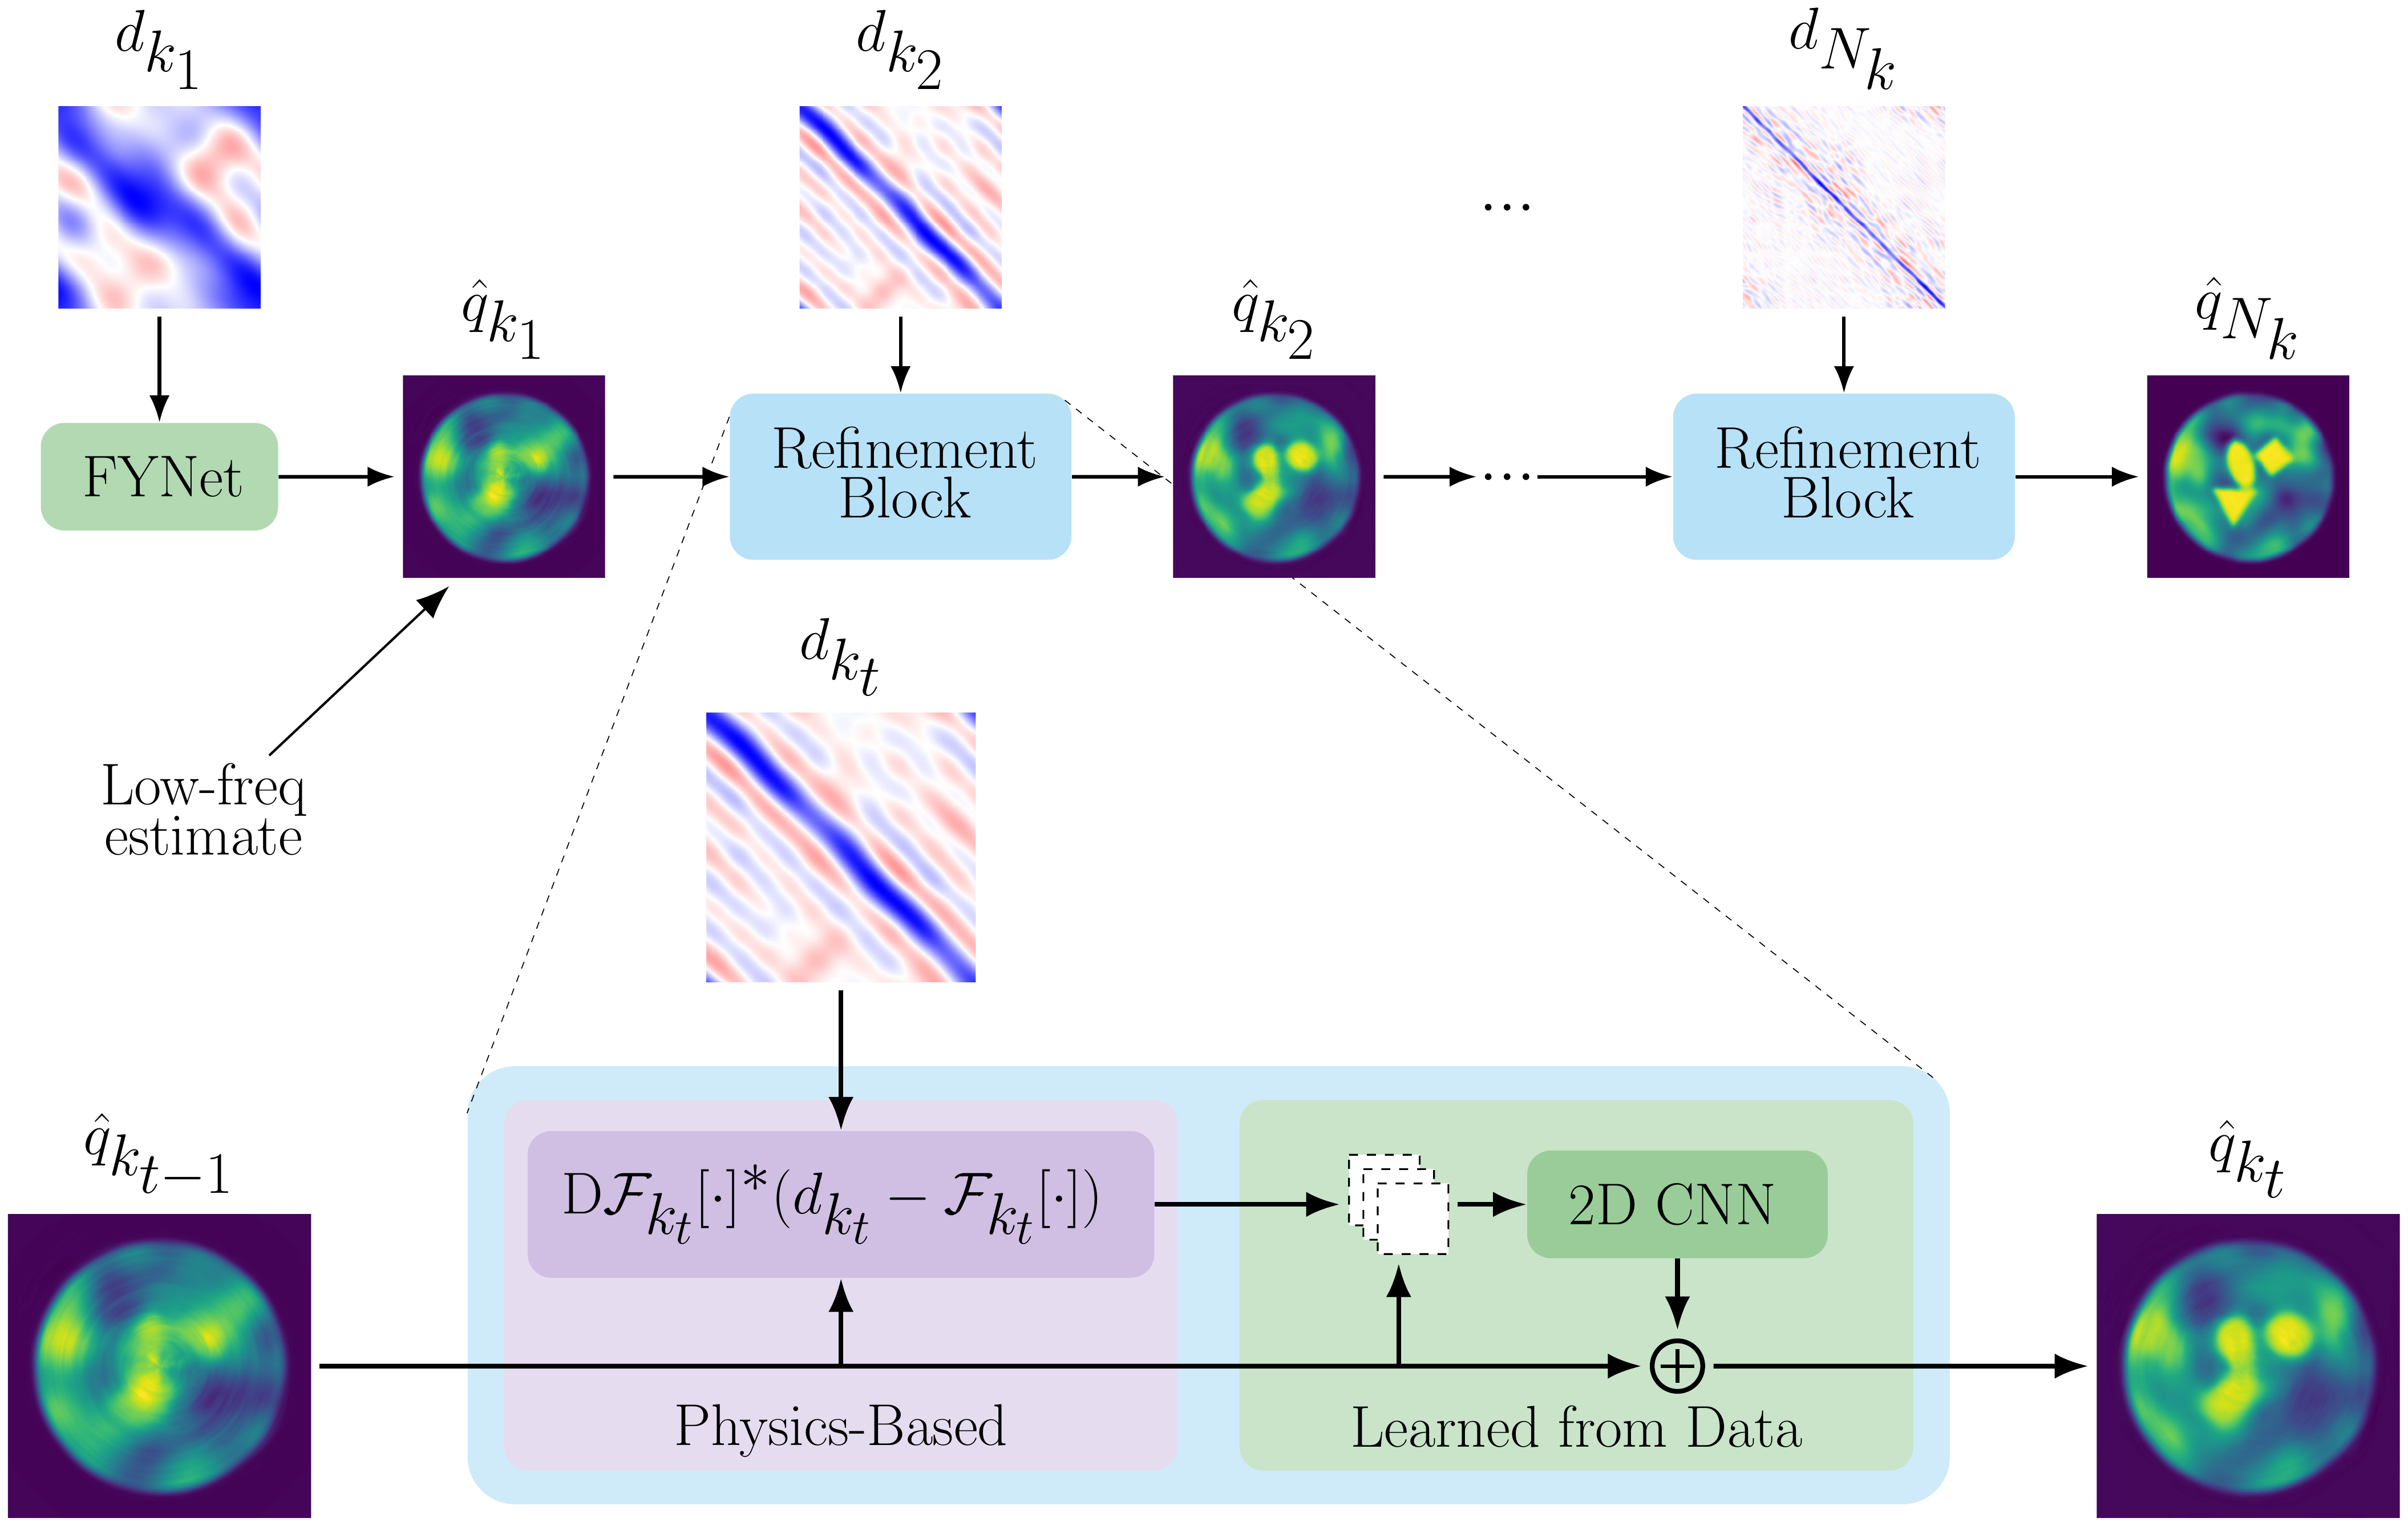

In [14]:
from IPython.display import Image, display
display(Image(filename=".github/assets/hpscnn-assets/hpscnn_architecture_both.png"))

## Imports and setup

In [3]:
from typing import Tuple, List, Iterable, Callable, Optional
import os
import logging
from dataclasses import dataclass, field
import tqdm
import tqdm.notebook
import tqdm.auto

import matplotlib.pyplot as plt
import numpy as np

# Set the preallocation for JAX before
import logging
from src.utils.loading import jax_setup, logging_setup
logging_setup("invsc", level=logging.WARNING)
jax_device = jax_setup(cpu_only=False, vram_fraction=0.3) # preallocation fraction
import jax
import jax.numpy as jnp
import jax.dlpack
print(f"Jax device: {jax_device}")

import torch
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {torch_device}")

# Data imports
from src.data.layout import RefDatasetLayout
from src.data.data_io import (
    load_hdf5_to_dict,
    load_multifreq_dataset,
    load_field_in_hdf5,
)
from src.data.datasets import (
    setup_dataset_linear,
    setup_preprocessed_predictions_dataset,
)
from src.data.data_naming_constants import KEYS_FOR_EXPERIMENT_INFO_OUT

# Neural network models
from src.models.FYNet import FYNetInverse
from src.models.MMGUBlock import MMGUBlock

# Solver imports
from solvers.hps.wave_scattering import HPSScatteringSolver
from solvers.hps.wave_scattering.solver_cache import SolverCache
from solvers.hps.wave_scattering.shared_solver import SharedSolver

# Training
from src.training_utils.loss_functions import MSEModule
from src.training_utils.train_loop import (
    train,
    evaluate_losses_on_dataloader,
    evaluate_losses_on_dataloader_only_cartesian,
)
from src.training_utils.make_predictions import (
    make_preds_on_dataset,
    make_preds_on_dataset_only_cartesian,
)

# Set seed for reproducibility
torch.random.manual_seed(583689)
np.random.seed(183345)
rng = np.random.default_rng(923041)

KeyboardInterrupt: 

In [ ]:
# File locations; update as needed
repo_dir = os.path.join(
    "/", "home-nfs", "oortsang", "model-guided-isp",
)
# For the underlying data
ref_dataset_dir = os.path.join(repo_dir, "dataset")
# For the HPS solver (single/double potential matrices prepared by matlab libraries)
hps_sd_mat_dir = os.path.join(repo_dir, "HPS_SD_matrices")

In [ ]:
# Data loading settings; update as needed
# nu_list = np.array([1,2,3,5,10])
nu_list = np.array([1,2,3,4,5,6,7,8,9,10]) # also referred to as kbar or k/2pi
subset_sizes = {
    "train": 100,
    "val": 10,
    "test": 10,
}

# Convenience values
subset_list = list(subset_sizes.keys())
nu_str_list = [f"{nu:d}" for nu in nu_list]
N_freqs = len(nu_list)
N_train = subset_sizes["train"]
N_val   = subset_sizes["val"]
N_test  = subset_sizes["test"]

In [ ]:
# Fetch dataset layout
layout = RefDatasetLayout(
    base_dir=ref_dataset_dir,
    nu_str_list=nu_str_list,
    subset_list=subset_list,
)

In [ ]:
# Load data from disk
subset_dd = {
    subset_name: load_multifreq_dataset(
        layout.get_all_meas_dirs(subset_name),
        truncate_num=subset_sizes[subset_name],
        load_cart=True,
    )[0]
    for subset_name in subset_list
}

# More convenient interfaces
train_dd = subset_dd["train"]
val_dd = subset_dd["val"]
test_dd = subset_dd["test"]
expt_info = {k: train_dd[k] for k in train_dd.keys() if k in KEYS_FOR_EXPERIMENT_INFO_OUT}
loaded_nu_sf = train_dd["nu_sf"]

# Fetch dimensions
N_x = expt_info["x_vals"].shape[0]
N_s = N_x
N_r = N_x

N_rho = expt_info["rho_vals"].shape[0]
N_theta = expt_info["theta_vals"].shape[0]

N_m = N_theta
N_h = N_m // 2

In [ ]:
# Set up solver
solver_cache = SolverCache(
    kbar_str_list=nu_str_list,
    grid_size=N_x,
    num_sources=N_s,
    num_receivers=N_r,
    default_l=3,
    default_p=16,
    hps_sd_mat_dir=hps_sd_mat_dir,
    cache_size=10, # can reduce if insufficient VRAM
)

## Polar/cartesian conversion
FYNet outputs predictions in polar coordinates, but we feed this into a 2D CNN expecting a cartesian representation

In [ ]:
from src.data.data_transformations import (
    prepare_polar_to_cart,
    prep_conv_interp_2d,
    prep_polar_padder,
    polar_pad_and_apply,
)
polar_to_cart_fn = prepare_polar_to_cart(
    expt_info["x_vals"],
    expt_info["theta_vals"],
    expt_info["rho_vals"],
    conv_op_device=torch_device,
    return_conv_tensors=False,
)

## HPS solver driver

In [ ]:
# Solver usage
def move_to_jax(x: np.ndarray | torch.Tensor) -> jax.Array:
    """Little helper to move numpy arrays and torch Tensors to jax"""
    return (
        jax.dlpack.from_dlpack(x) # no copy
        if isinstance(x, torch.Tensor)
        else jnp.asarray(x)
    )

def compute_neg_grad_err_meas(
    hss: HPSScatteringSolver,
    q_arr: np.ndarray | torch.Tensor,
    dk_arr: np.ndarray | torch.Tensor,
    jax_device: jax.Device = jax.devices()[0],
) -> np.ndarray:
    """Computes the negative gradient of error in measurement-space
    with the provided HPS solver.
        g(q, dk) := -DF_k[q]^* (d_k-F_k[q])
                  = - grad_q (1/2 * ||d_k-F_k[q]||^2)
    Solves two PDEs: one for F_k[q], and another to apply DF_k[q]^*(d_k-F_k[q]).

    Note: HPS solver expects inputs represented on a quadtree of
    panels discretized on Chebyshev grids; The QtU and UtQ operators of the hss object
    move between this quadtree/hps-tree grid and a uniform grid.

    Parameters:
        q_arr (np.ndarray or torch.Tensor): shape (N_samples, N_x, N_x); real-valued
            Array of scattering potentials, expected in cartesian coordinates
            and represented on a uniform grid; this function handles conversion
            to the quadtree representation for HPS
        dk_arr (ndarray or torch.Tensor): shape (N_samples, N_s, N_r); complex-valued
            Array of true wave scattering measurements
        jax_device (jax.Device):
            Device used by HPS
    Returns:
        g_arr (np.ndarray): shape (N_samples, N_x, N_x); real-valued
            Array of negative-gradient-of-error-in-measurement-space values
            Note this lives in the same space as q_arr.
    """
    # Move to JAX
    jq_arr  = move_to_jax(q_arr)
    jdk_arr = move_to_jax(dk_arr)

    # Iterate through scattering potentials and compute
    # the negative gradient of error in measurement space
    jg_arr = np.zeros_like(q_arr)
    # for i in tqdm.notebook.tqdm(range(jq_arr.shape[0])):
    for i in tqdm.auto.tqdm(range(jq_arr.shape[0]), leave=False):
        jq_unif_i = jq_arr[i]
        jqi_hpst = hss.UtQ.apply(jq_unif_i) # move to quadtree grid
        hss_i = SharedSolver(hss, jqi_hpst, device=jax_device) # Saves intermediate work
        hss_i.forward_interior() # Build HPS tree
        pred_meas = hss_i.forward_exterior() # Predicted u_sc^ext
        err_meas  = dk_arr[i].T - pred_meas # Transpose because axis conventions were flipped
        jg_hpst   = hss_i.vjp_exterior(err_meas) # Apply the derivative operator's adjoint
        jg_arr[i]  = hss.QtU.apply(jg_hpst) # bring back to uniform grid
    g_arr = np.asarray(jg_arr)
    return g_arr

## Per-frequency logging and training

In [ ]:
# First, prepare the logging functions
def print_metrics(label: str, loss_values_dd: dict):
    metric_str = ", ".join([
        f"{k.lower()} {v.mean().item():8.5f}"
        for k,v in loss_values_dd.items()
    ])
    print(f"{label.rjust(12)}: {metric_str}")

def prep_fynet_logger(train_dloader, val_dloader, loss_fn_dd: dict, torch_device=torch_device):
    """Logging for FYNet blocks"""
    def log_function(model, epoch):
        nonlocal train_dloader, val_dloader, loss_fn_dd, torch_device
        epoch_prefix = f"Epoch {epoch:3d}"
        
        with torch.no_grad():
            # 1. Evaluate on training set
            train_loss_values_dd = evaluate_losses_on_dataloader(
                model, train_dloader, loss_fn_dd, torch_device
            )
            print_metrics(f"{epoch_prefix} Train", train_loss_values_dd)
            # 2. Evaluate on validation set
            val_loss_values_dd = evaluate_losses_on_dataloader_only_cartesian(
                model, val_dloader, loss_fn_dd, torch_device,
            )
            print_metrics(f"{' '*len(epoch_prefix)}   Val", val_loss_values_dd)
    return log_function

def prep_mmgu_logger(train_dloader, val_dloader, loss_fn_dd: dict, torch_device=torch_device):
    """Logging for MMGU blocks"""
    def log_function(model, epoch):
        nonlocal train_dloader, val_dloader, loss_fn_dd, torch_device
        epoch_prefix = f"Epoch {epoch:3d}"
        with torch.no_grad():
            common_args = dict(
                # loss_fn_dd=loss_fn_dd,
                cart_loss_fn_dict=loss_fn_dd,
                device=torch_device,
                model_outputs_tuple=False,
                model_takes_x_mh=True,
            )
            # 1. Evaluate on training set
            train_loss_values_dd = evaluate_losses_on_dataloader_only_cartesian(
                model, train_dloader, **common_args
            )
            print_metrics(f"{epoch_prefix} Train", train_loss_values_dd)
            # 2. Evaluate on validation set
            val_loss_values_dd = evaluate_losses_on_dataloader_only_cartesian(
                model, val_dloader, **common_args,
            )
            print_metrics(f"{' '*len(epoch_prefix)}   Val", val_loss_values_dd)
    return log_function

In [ ]:
# Next the training logic
@dataclass
class OptHyperparams:
    """Wrapper to organize the optimization hyperparameters"""
    n_epochs: int
    lr_init: float = 3e-4
    lr_min: float = 1e-5
    weight_decay: float = 0
    momentum: float = 0
    batch_size: int = 16
    use_lpf: bool = False

def train_fynet_block(
    fynet_model: FYNetInverse,
    opt_hp: OptHyperparams,
    device: torch.device,
    train_dloader: torch.utils.data.DataLoader,
    val_dloader: torch.utils.data.DataLoader,
    loss_function: MSEModule,
    n_epochs_per_log: int = 5,
) -> FYNetInverse:
    """Training loop for FYNet"""
    fynet_logger = prep_fynet_logger(train_dloader, val_dloader, loss_fn_dd)
    return train(
        fynet_model,
        device=device,
        n_epochs=opt_hp.n_epochs,
        lr_init=opt_hp.lr_init,
        eta_min=opt_hp.lr_min,
        weight_decay=opt_hp.weight_decay,
        momentum=opt_hp.momentum,
        train_loader=train_dloader,
        n_epochs_per_log=n_epochs_per_log,
        log_function=fynet_logger,
        loss_function=loss_function,
    )
def train_mmgu_block(
    mmgu_model: MMGUBlock,
    opt_hyperparams: OptHyperparams,
    device: torch.device,
    train_dloader: torch.utils.data.DataLoader,
    val_dloader: torch.utils.data.DataLoader,
    loss_function: MSEModule,
    n_epochs_per_log: int = 5,
) -> MMGUBlock:
    mmgu_logger = prep_mmgu_logger(train_dloader, val_dloader, loss_fn_dd)
    """Training loop for MMGU blocks"""
    return train(
        mmgu_model,
        device=device,
        n_epochs=opt_hp.n_epochs,
        lr_init=opt_hp.lr_init,
        eta_min=opt_hp.lr_min,
        weight_decay=opt_hp.weight_decay,
        momentum=opt_hp.momentum,
        train_loader=train_dloader,
        n_epochs_per_log=n_epochs_per_log,
        log_function=mmgu_logger,
        loss_function=loss_function,
    )

def train_model_block(model: FYNetInverse | MMGUBlock, *args, **kwargs) -> FYNetInverse | MMGUBlock:
    """Shared interface for FYNet/MMGU model training"""
    if isinstance(model, FYNetInverse):
        return train_fynet_block(model, *args, **kwargs)
    elif isinstance(model, MMGUBlock):
        return train_mmgu_block(model, *args, **kwargs)
    else:
        raise ValueError(f"Unrecognized model type {type(model)}")

## Per-frequency data loading
Load data at each frequency

In [ ]:
def get_freq_axis_idx(nu: float|str, loaded_nu: np.ndarray, atol=1e-4) -> int:
    """Get the index for the data's frequency axis"""
    nu_float = float(nu)
    dists = np.abs(loaded_nu-nu_float)
    min_idx = np.argmin(dists)
    if dists[min_idx] < atol:
        return min_idx
    else:
        raise ValueError(
            f"_get_freq_axis_idx did not find {nu} within {loaded_nu} "
            f"within a tolerance of {atol}"
        )

def prep_fynet_dataloader(
    data_dict: dict,
    nu: float,
    use_lpf: bool = False,
    batch_size: int = 16,
    loaded_nu: np.ndarray=loaded_nu_sf,
) -> torch.utils.data.DataLoader:
    """Wrapper to prepare the FYNet-type dataset"""
    freq_axis_idx = get_freq_axis_idx(nu, loaded_nu)
    q_polar_orig = data_dict["q_polar"]
    if use_lpf:
        q_polar_tgt = data_dict["q_polar_lpf"][:, freq_axis_idx, ...]
    else:
        q_polar_tgt = q_polar_orig
    d_mh = data_dict["d_mh"][:, freq_axis_idx, ...]
    dset = setup_dataset_linear(q_polar_tgt, d_mh, q_polar_orig)
    dloader = torch.utils.data.DataLoader(dset, batch_size=batch_size)
    return dloader

def prep_mmgu_dataloader(
    data_dict: dict,
    nu: float,
    pred_q_arr: np.ndarray,
    pred_g_arr: np.ndarray,
    use_lpf: bool = False,
    batch_size: int = 16,
    loaded_nu: np.ndarray=loaded_nu_sf,
) -> torch.utils.data.DataLoader:
    """Wrapper to prepare the MMGU-type dataset, with g values"""
    freq_axis_idx = get_freq_axis_idx(nu, loaded_nu)
    q_cart_orig = data_dict["q_cart"]
    if use_lpf:
        q_cart_tgt = data_dict["q_cart_lpf"][:, freq_axis_idx, ...]
    else:
        q_cart_tgt = q_cart_orig
    d_rs = data_dict["d_rs"][:, freq_axis_idx, ...]
    dset = setup_preprocessed_predictions_dataset(
        pred_q_arr, d_rs, q_cart_tgt, q_cart_orig, pred_g_arr,
    )
    dloader = torch.utils.data.DataLoader(dset, batch_size=batch_size)
    return dloader

## Model setup

In [ ]:
# FYNet hyperparameters
fynet_c1d = 24
fynet_c2d = 24
fynet_w1d = 40
fynet_w2d = 5
fynet_num_cnn_1d = 3
fynet_num_cnn_2d = 3

# MMGU hyperparameters
mmgu_c2d = 36
mmgu_w2d = 5
mmgu_num_cnn_2d = 4

In [ ]:
fynet_block = FYNetInverse(
    N_h=N_h,
    N_rho=N_rho,
    c_1d=fynet_c1d,
    c_2d=fynet_c2d,
    w_1d=fynet_w1d,
    w_2d=fynet_w2d,
    N_cnn_1d=fynet_num_cnn_1d,
    N_cnn_2d=fynet_num_cnn_2d,
)

In [ ]:
mmgu_config = dict(
    N_x=N_x,
    N_y=N_x,
    c2d_hidden=mmgu_c2d,
    kernel_size=mmgu_w2d,
    N_cnn_layers=mmgu_num_cnn_2d,
    skip_connection=True,
)

In [ ]:
model_freq_list = [*nu_str_list] # in order

mmgu_block_list = [MMGUBlock(**mmgu_config) for _i in range(len(model_freq_list)-1)]
model_tuple_list = list(zip(
    model_freq_list,
    [fynet_block, *mmgu_block_list]
))

In [ ]:
print(f"Frequency blocks' nu(=k/2pi) values: {', '.join(model_freq_list)}")

## Plotting code

In [ ]:
# vis_idcs = [0, 1]
def plot_sample_images(pred_q_arr: np.array, obs_q_arr: np.ndarray, vis_idcs: list, vmax_manual: Optional[float]=None):
    """Plot a few sample images during training
    """
    num_vis = len(vis_idcs)
    fig, all_axes = plt.subplots(
        num_vis, 3, figsize=(3*3, 3*num_vis), layout="constrained", dpi=100, squeeze=False,
    )
    err_max = 0
    vis_cb_err_list = []

    # Column headers
    all_axes[0, 0].set_title(f"Ground truth")
    all_axes[0, 1].set_title(f"Predicted")
    all_axes[0, 2].set_title(f"Absolute errors")

    for i, row_axes in enumerate(all_axes):
        # Plot one sample per row
        ax0, ax1, ax2 = row_axes
        vis_idx = vis_idcs[i]
        pred_i = pred_q_arr[vis_idx]
        obs_i = obs_q_arr[vis_idx]

        ax0.imshow(obs_i, cmap="viridis", vmin=0, vmax=2)
        ax1.imshow(pred_i, cmap="viridis", vmin=0, vmax=2)

        vis_abs_errs = np.abs(pred_i - obs_i)
        err_max = max(err_max, vis_abs_errs.max())
        cb_err = ax2.imshow(vis_abs_errs, cmap="Reds", vmin=0)
        vis_cb_err_list.append(cb_err)

        vis_rel_l2_err = np.linalg.norm(vis_abs_errs) / np.linalg.norm(obs_i)
        ax0.set_ylabel(f"Sample {vis_idx}\nRel l2 err: {vis_rel_l2_err:.3f}")

        for ax in row_axes:
            ax.set_xticks([])
            ax.set_yticks([])
    err_max = err_max if vmax_manual is None else vmax_manual
    for i in range(num_vis):
        # Update the colorbar scaling for each of the absolute error plots
        vis_cb_err_list[i].set_clim(0, err_max)
        fig.colorbar(vis_cb_err_list[i], ax = all_axes[i,:].ravel().tolist())
    return fig, all_axes

## Training loop

In [ ]:
# Loss/evaluation metrics setup
# MSEModule holds several different loss/evaluation metrics
loss_module = MSEModule()
loss_fn_dd = {
    "mse": loss_module.mse,
    "psnr": loss_module.psnr,
    "rel_l2": loss_module.relative_l2_error,
}

In [ ]:
# Set the optimization parameters here; for simplicity share between fynet and mmgu
opt_hp = OptHyperparams(
    n_epochs=200, # short run for demonstrative purposes, but typically the network has not converged by this point
    lr_init=3e-4,
    lr_min=1e-5,
    weight_decay=1e-3,
    momentum=0,
    batch_size=16,
    use_lpf=False,
)
n_epochs_per_log = 25
eval_batch_size = 100

In [ ]:
%%time

# Primary training loop -- ILLUSTRATIVE PUPRPOSES ONLY
vis_idcs = [0, 1, 5] # Pick several indices from the validation set to display after each stage

# Prepare arrays to hold the intermediate q reconstructions
# and corresponding g for the negative-gradient-of-error-in-measurement-space.
subset_pred_q_cart = {
    subset_name:
    np.zeros((subset_size, N_freqs, N_x, N_x), dtype=np.float32)
    for subset_name, subset_size in subset_sizes.items()
}
subset_pred_g_cart = {
    subset_name:
    np.zeros((subset_size, N_freqs-1, N_x, N_x), dtype=np.float32)
    for subset_name, subset_size in subset_sizes.items()
}
subset_loss_values = {subset_name: [] for subset_name in subset_list}

# Take one step through each of the frequencies
for freq_idx in range(N_freqs):
    # freq_idx is the index corresponding to the frequency block
    # nu_fi is the (non-angular) wavenumber of the frequency block

    # 1. Load relevant data
    nu_fi, model_fi = model_tuple_list[freq_idx]
    is_fynet = not isinstance(model_fi, MMGUBlock)
    model_type = "FYNet" if is_fynet else "MMGU"
    print(f"~~~ Frequency #{freq_idx+1}: nu={nu_fi} ({model_type} Block) ~~~")
    print(f"Preparing dataloader...")
    # FYNet and MMGU expect different dataloaders, since MMGU also needs the
    # g_cart calculated by the HPS solver
    if is_fynet:
        subset_dloader_dd = {
            subset_name: prep_fynet_dataloader(
                data_dict=subset_dd[subset_name],
                nu=nu_fi,
                use_lpf=opt_hp.use_lpf,
                batch_size=(
                    opt_hp.batch_size if subset_name=="train" else eval_batch_size
                ),
            )
            for subset_name in subset_list
        }
    else:
        subset_dloader_dd = {
            subset_name: prep_mmgu_dataloader(
                data_dict=subset_dd[subset_name],
                nu=nu_fi,
                pred_q_arr=subset_pred_q_cart[subset_name][:, freq_idx-1],
                pred_g_arr=subset_pred_g_cart[subset_name][:, freq_idx-1],
                use_lpf=opt_hp.use_lpf,
                batch_size=(
                    opt_hp.batch_size if subset_name=="train" else eval_batch_size
                ),
            )
            for subset_name in subset_list
        }
    train_dloader = subset_dloader_dd["train"]
    val_dloader = subset_dloader_dd["val"]

    # 2. Train the relevant model block
    print(f"Training block...")
    model_fi = train_model_block(
        model_fi,
        opt_hp,
        device=torch_device,
        train_dloader=train_dloader,
        val_dloader=val_dloader,
        loss_function=loss_module,
        n_epochs_per_log=n_epochs_per_log,
    )

    # 3. Evaluate model on each dataset
    print(f"Making predictions...")
    preds_args_shared = dict(
        experiment_info=expt_info,
        device=torch_device,
        output_dir=None,
        evaluate_outputs=True,
        shard_size=None,
    )
    for subset_name in subset_list:
        if is_fynet:
            # For FYNet, we need to send the predictions from
            # the polar grid onto a cartesian representation
            outs = make_preds_on_dataset(
                model=model_fi,
                dloader=subset_dloader_dd[subset_name],
                polar_loss_fn_dict=loss_fn_dd,
                to_cart_fn=polar_to_cart_fn,
                **preds_args_shared,
            )
            pred_q_cart_fi = outs[1]
            pred_loss_values_dd = outs[2]
        else:
            outs = make_preds_on_dataset_only_cartesian(
                model=model_fi,
                dloader=subset_dloader_dd[subset_name],
                cart_loss_fn_dict=loss_fn_dd,
                model_outputs_tuple=False,
                model_takes_x_mh=True,
                **preds_args_shared,
            )
            pred_q_cart_fi = outs[0]
            pred_loss_values_dd = outs[1]
        # Track the predictions/loss values
        subset_pred_q_cart[subset_name][:, freq_idx] = pred_q_cart_fi
        subset_loss_values[subset_name].append(pred_loss_values_dd)
        print_metrics(
            f"{subset_name.rjust(5)}, freq-block #{freq_idx+1}",
            pred_loss_values_dd,
        )

    # 5.  Run solver for next step freq_idx>=1
    next_freq_idx = freq_idx + 1
    if next_freq_idx < N_freqs:
        print(f"Running the HPS solver for frequency block #{next_freq_idx+1}...")
        hss_nu = solver_cache.get_solver(nu_str_list[next_freq_idx])
        for subset_name in subset_list:
            pred_q_arr_fi = subset_pred_q_cart[subset_name][:, freq_idx]
            # This applies the HPS scattering solver
            pred_g_arr_fi = compute_neg_grad_err_meas(
                hss_nu,
                pred_q_arr_fi,
                subset_dd[subset_name]["d_rs"][:, next_freq_idx], # use next frequency
                jax_device=jax_device,
            )
            subset_pred_g_cart[subset_name][:, freq_idx] = pred_g_arr_fi

    # 6. Visualize a few predictions
    fig, axes = plot_sample_images(
        subset_pred_q_cart["val"][:, freq_idx], # predicted
        subset_dd["val"]["q_cart"][:], # observed
        vis_idcs, # selected indices for visualization
        vmax_manual=2, # so vmax values are maintained across frequency blocks and is calibrated to q_cart's max of 2
    )
    fig.suptitle(
        f"Predictions from the validation set at k/2π={nu_fi}"
    )
    plt.show()

print(f"Finished training!")

## Inference

In [ ]:
def run_pipeline_inference(
    inference_dict: dict,
    model_tuple_list: list,
    solver_cache: SolverCache,
    nu_str_list: list,
    N_x: int,
    eval_batch_size: int,
    torch_device: torch.device,
    jax_device: jax.Device,
    expt_info: dict,
    loss_fn_dd: dict,
    polar_to_cart_fn: Callable,
    use_lpf: bool = False,
):
    """Performs block-by-block sequential inference on a specified data dictionary.

    Returns:
        dict: Dictionary containing predicted 'pred_q_cart', 'pred_g_cart', and
        'loss_values'.
    """
    N_blocks = len(model_tuple_list)
    subset_size = inference_dict["sample_completion"].shape[0]

    pred_q_cart = np.zeros((subset_size, N_blocks, N_x, N_x), dtype=np.float32)
    pred_g_cart = np.zeros(
        (subset_size, N_blocks - 1, N_x, N_x), dtype=np.float32
    )
    loss_values = []

    preds_args_shared = dict(
        experiment_info=expt_info,
        device=torch_device,
        output_dir=None,
        evaluate_outputs=True,
        shard_size=None,
    )

    for freq_idx in range(N_blocks):
        nu_fi, model_fi = model_tuple_list[freq_idx]
        is_fynet = not isinstance(model_fi, MMGUBlock)

        if is_fynet:
            dloader = prep_fynet_dataloader(
                data_dict=inference_dict,
                nu=nu_fi,
                use_lpf=use_lpf,
                batch_size=eval_batch_size,
            )
        else:
            dloader = prep_mmgu_dataloader(
                data_dict=inference_dict,
                nu=nu_fi,
                pred_q_arr=pred_q_cart[:, freq_idx - 1],
                pred_g_arr=pred_g_cart[:, freq_idx - 1],
                use_lpf=use_lpf,
                batch_size=eval_batch_size,
            )

        if is_fynet:
            outs = make_preds_on_dataset(
                model=model_fi,
                dloader=dloader,
                polar_loss_fn_dict=loss_fn_dd,
                to_cart_fn=polar_to_cart_fn,
                **preds_args_shared,
            )
            pred_q_cart_fi = outs[1]
            pred_loss_values_dd = outs[3]
        else:
            outs = make_preds_on_dataset_only_cartesian(
                model=model_fi,
                dloader=dloader,
                cart_loss_fn_dict=loss_fn_dd,
                model_outputs_tuple=False,
                model_takes_x_mh=True,
                **preds_args_shared,
            )
            pred_q_cart_fi = outs[0]
            pred_loss_values_dd = outs[1]

        pred_q_cart[:, freq_idx] = pred_q_cart_fi
        loss_values.append(pred_loss_values_dd)

        next_freq_idx = freq_idx + 1
        if next_freq_idx < N_blocks:
            hss_nu = solver_cache.get_solver(nu_str_list[next_freq_idx])
            pred_g_arr_fi = compute_neg_grad_err_meas(
                hss_nu,
                pred_q_cart_fi,
                inference_dict["d_rs"][:, next_freq_idx],
                jax_device=jax_device,
            )
            pred_g_cart[:, freq_idx] = pred_g_arr_fi

    return {
        "pred_q_cart": pred_q_cart,
        "pred_g_cart": pred_g_cart,
        "loss_values": loss_values,
    }

In [ ]:
# Load more of the test set
more_test_dict, more_expt_info = load_multifreq_dataset(
    layout.get_all_meas_dirs("test"),
    truncate_num=100,
    load_cart=True,
)

In [ ]:
%%time
# Displayed time is from an A4000
more_test_outs = run_pipeline_inference(
    more_test_dict,
    model_tuple_list,
    solver_cache=solver_cache,
    nu_str_list=nu_str_list,
    N_x=N_x,
    eval_batch_size=100,
    torch_device=torch_device,
    jax_device=jax_device,
    expt_info=more_expt_info,
    loss_fn_dd=loss_fn_dd,
    polar_to_cart_fn=polar_to_cart_fn,
    use_lpf=False,
)

In [ ]:
fig, axes = plot_sample_images(
    more_test_outs["pred_q_cart"][:, -1], # predicted
    more_test_dict["q_cart"][:], # observed
    [0, 10, 20], # selected indices for visualization
    vmax_manual=2.0,
)
fig.suptitle(
    f"Predictions from the test set at frequency k/2π={nu_fi}"
)
plt.show()

In [ ]:
test_rel_l2_mean = more_test_outs["loss_values"][-1]["rel_l2"].mean().item()
test_rel_l2_std = more_test_outs["loss_values"][-1]["rel_l2"].std().item()
print(f"Among the test samples, HPS-CNN achieves a relative l2 error of {test_rel_l2_mean:.5e}±{test_rel_l2_std:.3e}")